## Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Evina Fitriyani | 5054251013 |

### Deskripsi Tugas

Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

## 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [3]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("data.csv")

print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data:")
print(df.dtypes)
print("\nStatistik deskriptif:")
print(df.describe())
print("\nJumlah missing value:")
print(df.isnull().sum().sort_values(ascending=False))

df.head()

Jumlah baris dan kolom: (569, 33)

Tipe data:
id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactne

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


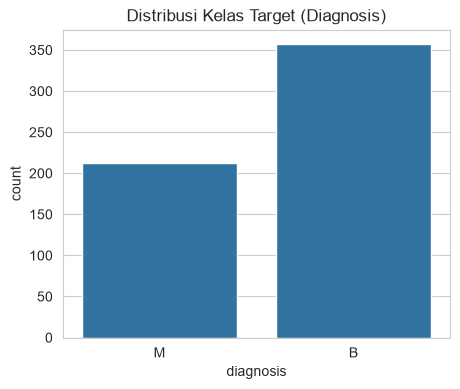

diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


In [4]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="diagnosis")
plt.title("Distribusi Kelas Target (Diagnosis)")
plt.show()

print(df["diagnosis"].value_counts(normalize=True))

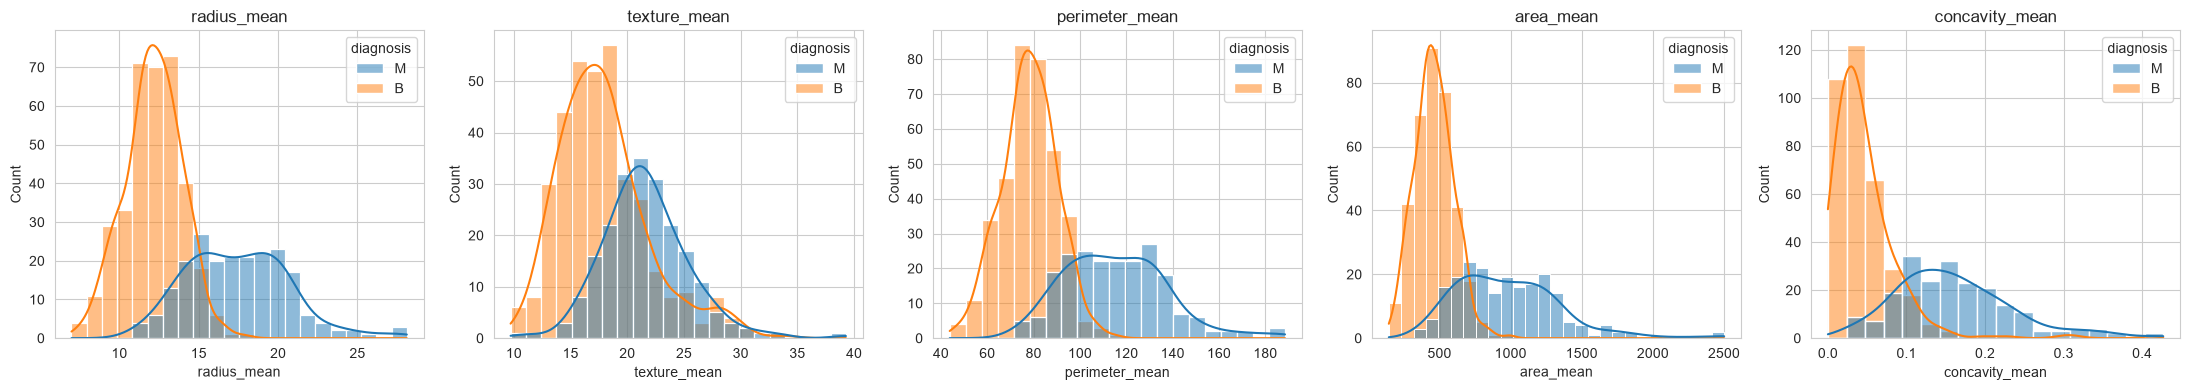

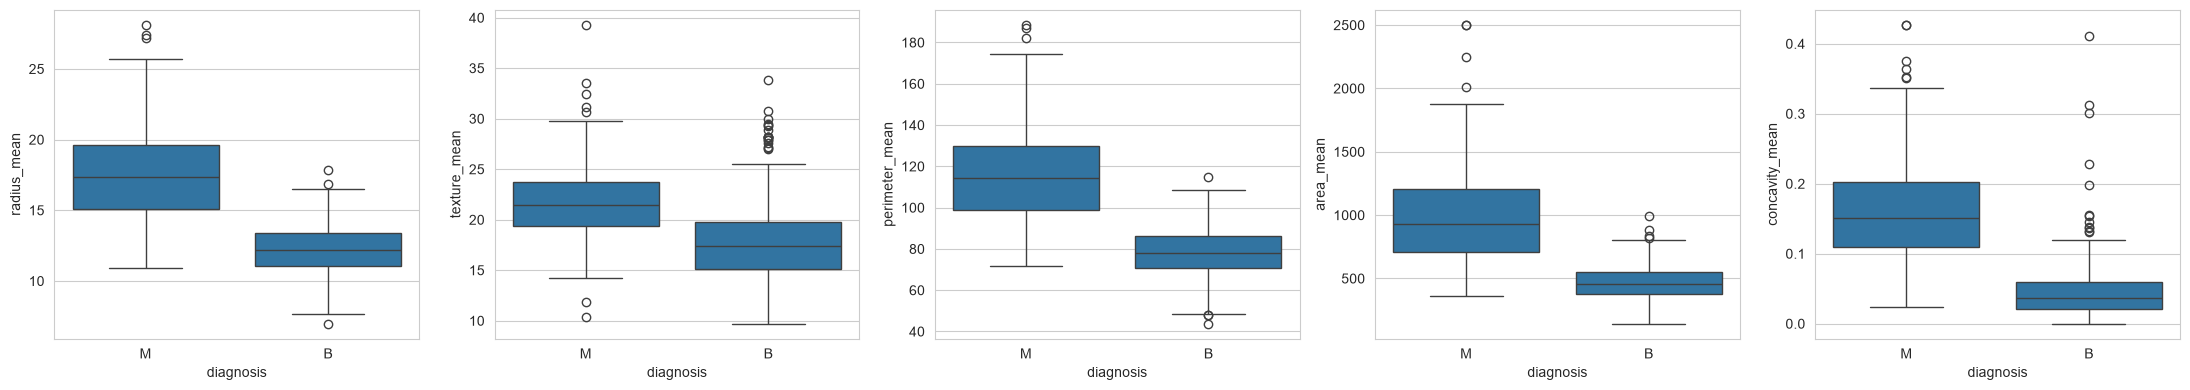

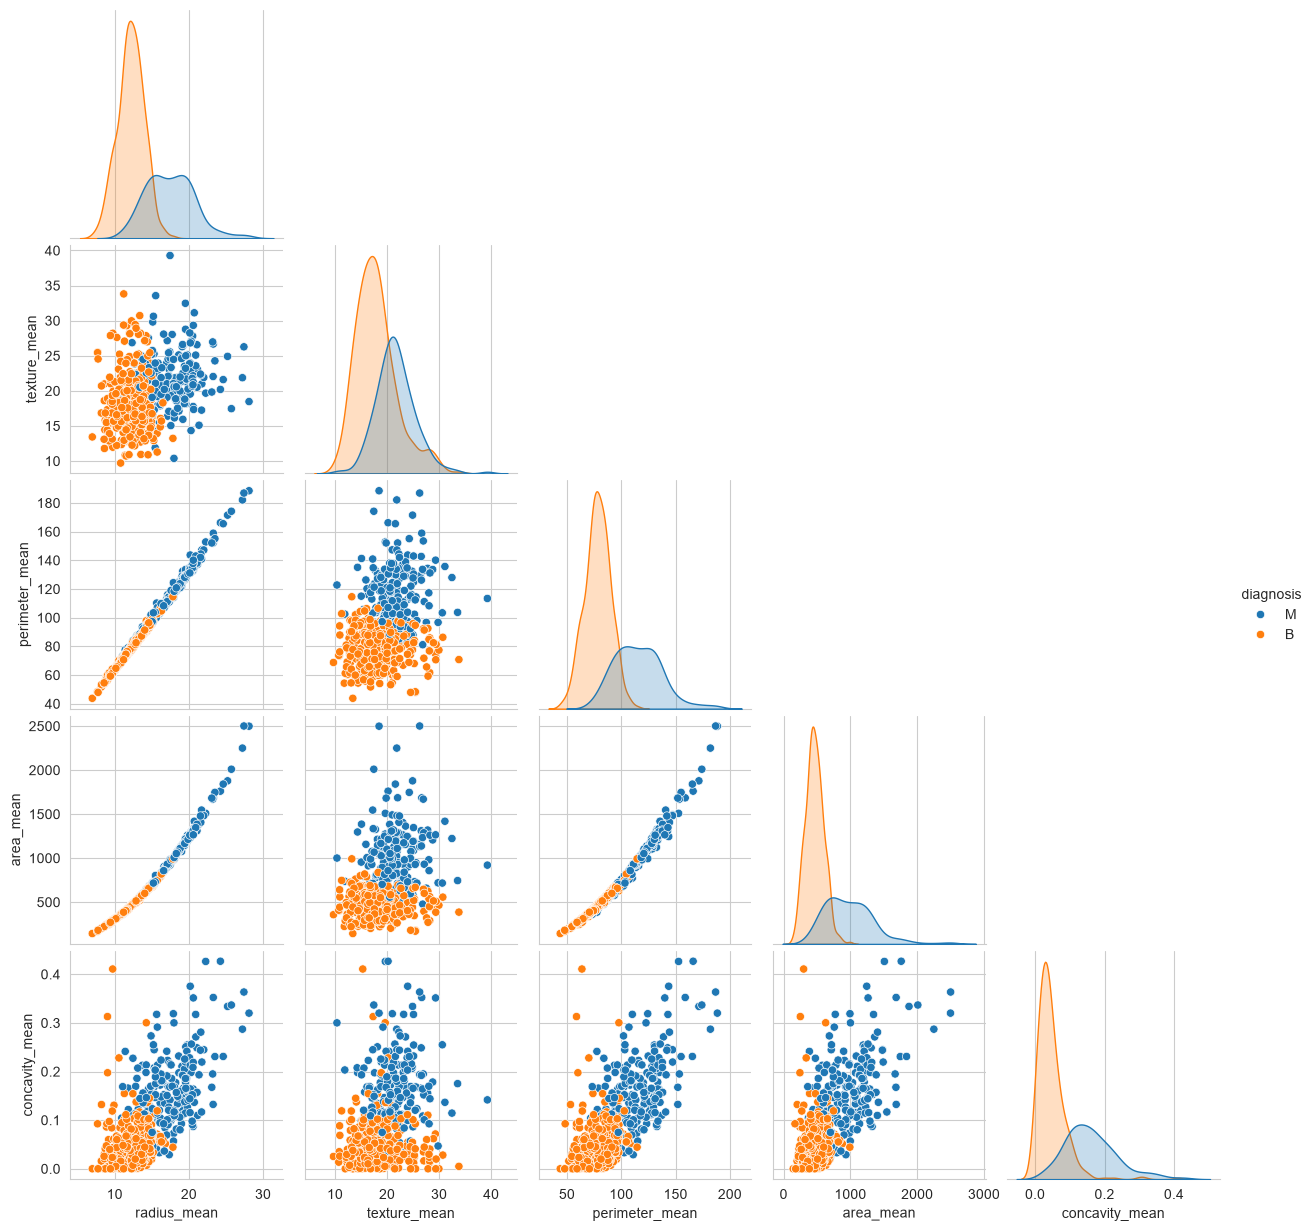

In [5]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.
sample_features = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "concavity_mean"]

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, sample_features):
    sns.histplot(data=df, x=col, hue="diagnosis", kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, sample_features):
    sns.boxplot(data=df, x="diagnosis", y=col, ax=ax)
plt.tight_layout()
plt.show()

sns.pairplot(df[sample_features + ["diagnosis"]], hue="diagnosis", corner=True)
plt.show()

Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

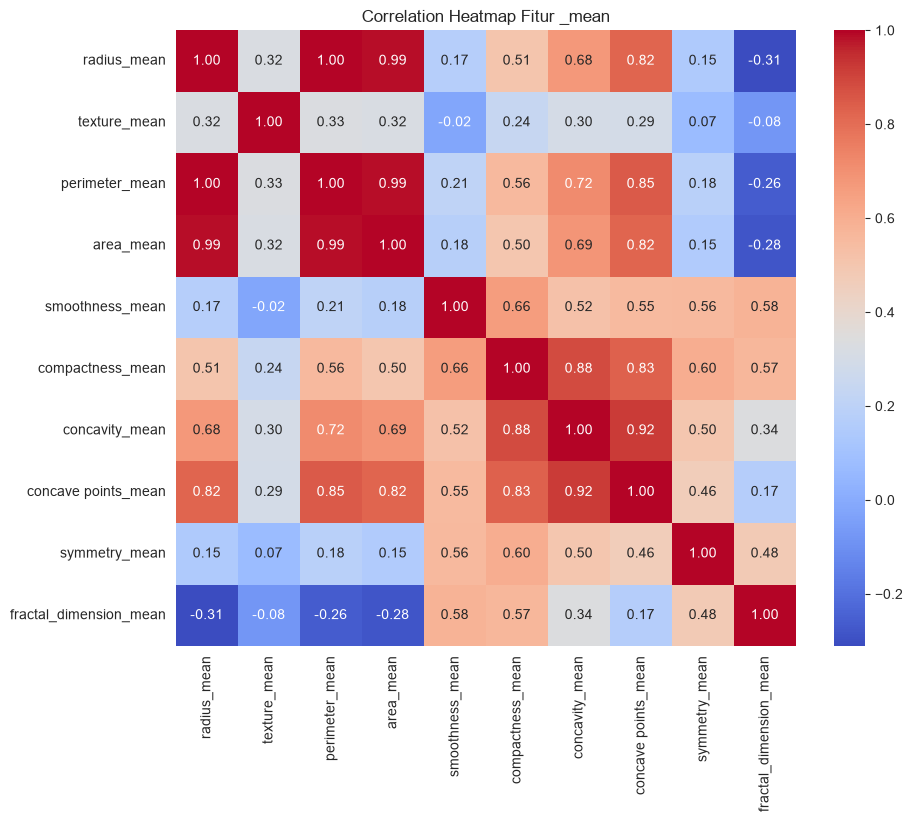

In [6]:
# EDA tambahan: correlation heatmap untuk fitur _mean (30 fitur terlalu padat kalau ditampilkan semua)
mean_cols = [c for c in df.columns if c.endswith("_mean")]

plt.figure(figsize=(10, 8))
sns.heatmap(df[mean_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap Fitur _mean")
plt.show()

## 2. Preprocessing

In [7]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# Kolom 'Unnamed: 32' adalah artefak export CSV (isinya kosong semua) -> drop
if "Unnamed: 32" in df.columns:
    df = df.drop(columns=["Unnamed: 32"])

# Kolom 'id' tidak informatif untuk model -> drop
df = df.drop(columns=["id"])

df.isnull().sum().sum()  # pastikan sudah 0

np.int64(0)

In [8]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Satu-satunya kolom kategorikal di dataset ini adalah target 'diagnosis' (M/B) -> encode jadi 0/1
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

In [9]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan feature scaling (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [10]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Eksperimen Model

### 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [11]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).
svm_linear = SVC(kernel="linear", random_state=RANDOM_STATE)
svm_linear.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_linear = svm_linear.predict(X_test_scaled)

print("Akurasi SVM kernel Linear:", accuracy_score(y_test, y_pred_linear))

Akurasi SVM kernel Linear: 0.9649122807017544


### 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [13]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.
svm_rbf = SVC(kernel="rbf", C=1.0, random_state=RANDOM_STATE)
svm_rbf.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_rbf = svm_rbf.predict(X_test_scaled)

print("Akurasi SVM kernel RBF:", accuracy_score(y_test, y_pred_rbf))

Akurasi SVM kernel RBF: 0.9736842105263158


### 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [15]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.
C_values = [0.01, 0.1, 1, 10, 100]
c_models = {}

for c in C_values:
    model = SVC(kernel="rbf", C=c, gamma="scale", random_state=RANDOM_STATE)
    model.fit(X_train_scaled, y_train)
    c_models[c] = model

In [16]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
c_results = []

for c, model in c_models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))
    c_results.append({"C": c, "Train Accuracy": train_acc, "Test Accuracy": test_acc})

c_df = pd.DataFrame(c_results)
c_df

,C,Train Accuracy,Test Accuracy
0,0.01,0.626374,0.631579
1,0.10,0.953846,0.947368
2,1.00,0.986813,0.973684
3,10.00,0.989011,0.973684
4,100.00,1.000000,0.964912


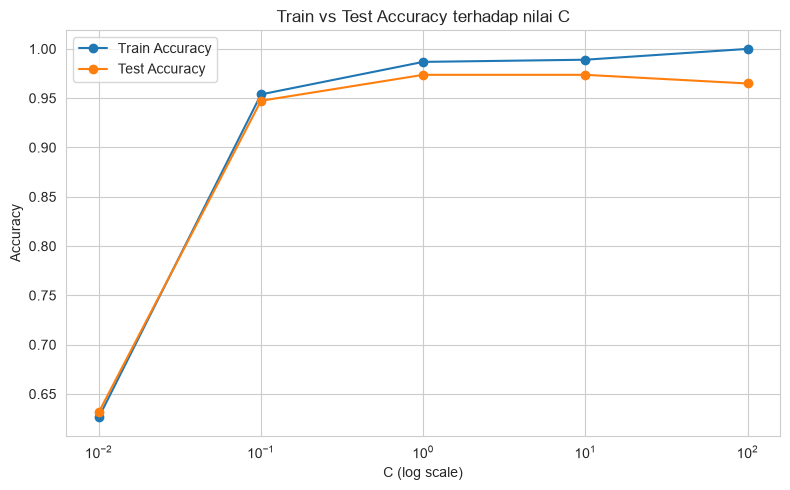

In [17]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.figure(figsize=(8, 5))
plt.plot(c_df["C"], c_df["Train Accuracy"], marker="o", label="Train Accuracy")
plt.plot(c_df["C"], c_df["Test Accuracy"], marker="o", label="Test Accuracy")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy terhadap nilai C")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Evaluasi Model

In [18]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def evaluate(y_true, y_pred, name):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
    }

eval_df = pd.DataFrame([
    evaluate(y_test, y_pred_linear, "SVM Linear"),
    evaluate(y_test, y_pred_rbf, "SVM RBF"),
])
eval_df

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM Linear,0.964912,1.0,0.904762,0.950000
1,SVM RBF,0.973684,1.0,0.928571,0.962963


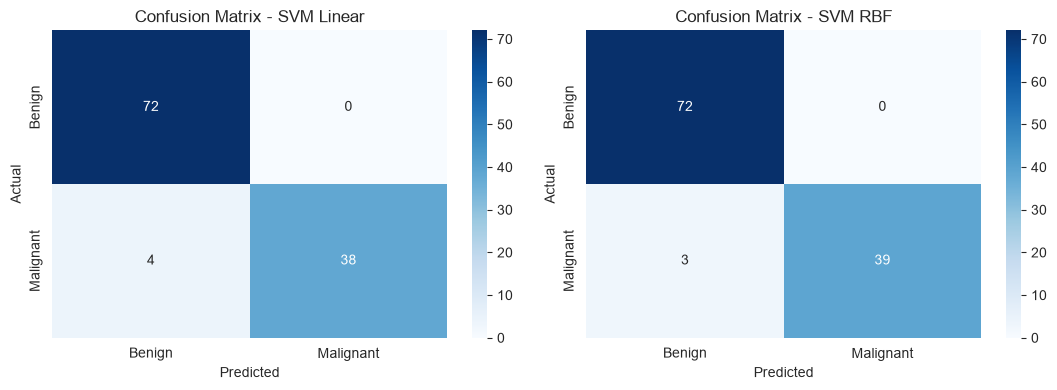

Classification Report - SVM Linear
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

Classification Report - SVM RBF
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [19]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm_linear = confusion_matrix(y_test, y_pred_linear)
sns.heatmap(cm_linear, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
axes[0].set_title("Confusion Matrix - SVM Linear")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

cm_rbf = confusion_matrix(y_test, y_pred_rbf)
sns.heatmap(cm_rbf, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
axes[1].set_title("Confusion Matrix - SVM RBF")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

print("Classification Report - SVM Linear")
print(classification_report(y_test, y_pred_linear, target_names=["Benign", "Malignant"]))

print("Classification Report - SVM RBF")
print(classification_report(y_test, y_pred_rbf, target_names=["Benign", "Malignant"]))

In [ ]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("data.csv")

print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data:")
print(df.dtypes)
print("\nStatistik deskriptif:")
print(df.describe())
print("\nJumlah missing value:")
print(df.isnull().sum().sort_values(ascending=False))

df.head()

Jumlah baris dan kolom: (569, 33)

Tipe data:
id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactne

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [20]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
print("Jumlah support vectors - SVM Linear:", svm_linear.support_vectors_.shape[0])
print("Per kelas (Benign, Malignant):", svm_linear.n_support_)

print("\nJumlah support vectors - SVM RBF:", svm_rbf.support_vectors_.shape[0])
print("Per kelas (Benign, Malignant):", svm_rbf.n_support_)

Jumlah support vectors - SVM Linear: 38
Per kelas (Benign, Malignant): [19 19]

Jumlah support vectors - SVM RBF: 107
Per kelas (Benign, Malignant): [50 57]


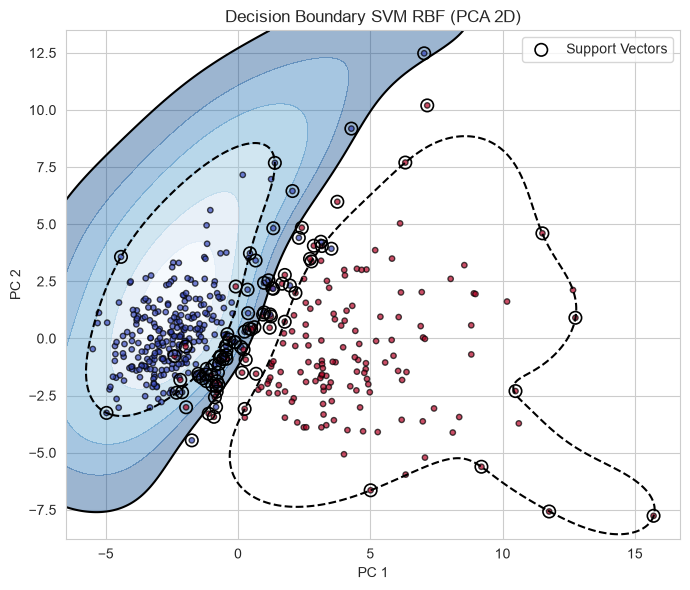

In [21]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_scaled)

# latih ulang model terbaik (kernel RBF) di ruang 2D hasil PCA khusus untuk visualisasi
svm_2d = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
svm_2d.fit(X_train_2d, y_train)

xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 300),
    np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 300)
)
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap="Blues", alpha=0.4)
plt.contour(xx, yy, Z, colors="k", levels=[-1, 0, 1], linestyles=["--", "-", "--"])
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap="coolwarm", s=15, edgecolors="k", alpha=0.7)
plt.scatter(svm_2d.support_vectors_[:, 0], svm_2d.support_vectors_[:, 1],
            facecolors="none", edgecolors="black", s=80, linewidths=1.2, label="Support Vectors")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Decision Boundary SVM RBF (PCA 2D)")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Analisis

**a. Perbandingan kernel Linear dan RBF**

Akurasi test kernel RBF berada di 0,9737, kernel Linear di 0,9649. Selisihnya cuma 0,88 poin persentase, jadi bukan perbedaan yang bisa dibilang signifikan.

Kalau dikaitkan sama EDA, hasil ini masuk akal. Boxplot dan pairplot di bagian awal nunjukin radius_mean, perimeter_mean, sama area_mean udah punya pemisahan yang cukup jelas antara kelas M dan B tumpang tindihnya cuma di rentang nilai tengah, sisanya udah kepisah rapi. Karena sebarannya sendiri udah hampir linear, kernel Linear aja udah cukup buat nangkep pola pemisahnya. RBF yang memproyeksikan data ke dimensi lebih tinggi cuma nambah sedikit, karena memang nggak banyak pola non-linear yang perlu ditangkap.

**b. Eksperimen nilai C**

Dari tabel c_df, di rentang C=0,01 sampai C=10 gap antara train dan test accuracy masih kecil (train 0,986–0,989, test 0,973–0,974). Baru di C=100 kelihatan jelas overfitting-nya: train accuracy tembus 1,0 (model udah hafal semua data training), tapi test accuracy malah turun ke 0,9649 lebih rendah dari C=1 dan C=10.

Ini ciri overfitting yang khas: kurva train terus naik mendekati 1, sementara kurva test sempat naik terus mendatar, lalu turun pas C=100. Artinya C yang kegedean bikin model terlalu maksa buat benar di data training (margin jadi sempit), akibatnya kemampuan generalisasinya malah berkurang.

**c. Jumlah support vectors**

Kernel Linear cuma pakai 38 support vectors (19 per kelas), sementara RBF pakai 107 (50 dan 57 per kelas) jauh lebih banyak. Ini nyambung langsung sama kompleksitas batas keputusan masing-masing kernel. Linear cuma butuh satu garis pemisah lurus, jadi titik yang jadi support vector cuma yang paling deket sama garis itu. RBF karena bisa bikin batas keputusan yang berkelok-kelok (non-linear), butuh lebih banyak titik data buat ngebentuk kurva pemisah yang lebih rumit. Jadi makin banyak support vectors, makin kompleks juga batas keputusan yang terbentuk.

## 6. Kesimpulan dan Saran

**Kesimpulan**

RBF sedikit unggul dari Linear (0,9737 vs 0,9649), tapi bedanya kecil banget dan nggak signifikan, karena data di dataset ini emang udah cukup terpisah secara linear. Eksperimen C nunjukin overfitting mulai muncul di C=100, sementara C=1 sampai C=10 kasih hasil paling seimbang antara train dan test accuracy. Dari sisi support vectors, RBF butuh jauh lebih banyak (107) dibanding Linear (38), yang nunjukin batas keputusannya lebih kompleks tapi kompleksitas tambahan itu nggak sebanding sama peningkatan akurasi yang didapat, yang cuma tipis.

**Saran**

Bisa dicoba kernel Polynomial sebagai pembanding tambahan antara Linear dan RBF, terus hyperparameter tuning pakai GridSearchCV buat cari kombinasi C dan gamma yang paling pas. Mengingat performa Linear udah kompetitif sama RBF, Linear juga layak dipertimbangkan jadi pilihan akhir karena lebih sederhana dan lebih cepat dihitung. Bisa juga dibandingin sama algoritma lain kayak Random Forest atau ANN buat lihat apakah performa SVM di dataset ini udah maksimal atau masih bisa ditingkatin lagi.